This code is used to make list of orthologs and non orthologs
First, i need to get unique id's from the tsv file from one side and the other to get the    

In [2]:
def get_ortho_list(chemin_fichier):
    listA = set()
    listB = set()
 
    with open(chemin_fichier,'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >=2:
                listA.add(parts[0])
                listB.add(parts[1])

    return listA,listB


In [3]:
def get_list_protein(chemin_fichier):
    listA = set()
    with open(chemin_fichier,'r') as f:
        for line in f:
            clean_id = line.strip()
            if clean_id:
                listA.add(clean_id)
    return listA

In [4]:
def extract_fasta_access(fasta_path):
    access = set()
    with open(fasta_path, 'r') as f:
        for line in f:
            if line.startswith(">"):
                parts = line.split('|')
            
                access.add(parts[1])
    return access

In [5]:
list_ortho_orgA, list_ortho_orgB = get_ortho_list('/home/cassandre/stage/Cassandre/ortho/liste_orthologs/MOUSE_HUMAN.tsv')

In [12]:
list_orgA_protein = get_list_protein("/home/cassandre/stage/Cassandre/ortho/list_protein_orthoinspector/HUMAN_protein.tsv")
list_orgB_protein = get_list_protein("/home/cassandre/stage/Cassandre/ortho/list_protein_orthoinspector/MOUSE_protein.tsv")

print(len(list_orgA_protein))
print(len(list_orgB_protein))

20591
21949


In [13]:
orgA_fasta_id = extract_fasta_access('/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000005640_9606.fa')
orgB_fasta_id = extract_fasta_access('/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000000589_10090.fa')

print(len(orgA_fasta_id))
print(len(orgB_fasta_id))


20659
21852


In [14]:
orgA_fasta_orthologs= orgA_fasta_id.intersection(list_ortho_orgA)
orgB_fasta_orthologs = orgB_fasta_id.intersection(list_ortho_orgB)



In [15]:
orgA_fasta_nonorthologs = (orgA_fasta_id - orgA_fasta_orthologs).intersection(list_orgA_protein)
orgB_fasta_nonorthologs = (orgB_fasta_id - orgB_fasta_orthologs).intersection(list_orgB_protein)

print(len(orgA_fasta_nonorthologs))
print(len(orgB_fasta_nonorthologs))

2571
3387


Liste of orthologs : human_fasta_orthologs & mouse_fasta_orthologs
Liste of non_orthologs : human_fasta_nonorthologs & mouse_fasta_nonorthologs

FROM HERE : i work on generating the distance to the closest neighbor for each protein in the proteome

In [16]:
import h5py
import numpy as np
import os
import faiss
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [17]:
def embedding_setup(path):
    ids = []
    embeddings = []

    with h5py.File(path, "r") as hf:
        for sequenceID in hf.keys():
            dataset = hf[sequenceID]
            # 1. On crée un array vide de la bonne taille en Float32
            # dataset.shape donne la dimension du vecteur (ex: 1024)
            vec = np.empty(dataset.shape, dtype='float32')
            
            # 2. On force la lecture directe dedans
            dataset.read_direct(vec)
            
            ids.append(sequenceID)
            embeddings.append(vec)
            
    # On empile tout à la fin
    embed_array = np.array(embeddings).astype('float32')
    
    return ids, embed_array
# have to use this function twice : once on query once on reference

In [18]:
def index_search_distances(emb_query,emb_ref):
  
    
    faiss.normalize_L2(emb_query)
    faiss.normalize_L2(emb_ref) #need to normalize to do the Inner product (dot product for cosine similarity)

    d = emb_ref.shape[1]  #tell faiss how many dimension we're working with
    index = faiss.IndexFlatIP(d) #indexflat = no compression (avoid info loss)  / IP = inner or dot product = the cosine similarity
    index.add(emb_ref) #store the information of organism2 to search through

    distances, indices = index.search(emb_query, k=1)#look through organism2 to compare with organism1 prot and look for the closest neighbor only
#distances store the distances, indices = the row number that match the indice of the list of ids !! genius congrats me :)

    return distances,indices

In [19]:
def extractname_frompath(organismpath) :
    filename = os.path.basename(organismpath)
    nomseul = os.path.splitext(filename)[0]
    label= nomseul.split('_')[0]

    return label

In [20]:
def get_similarity_dataframe(id1, emb1, id2, emb2, label1, label2):
  
    #FAISS 
    sim1_2, idx1_2 = index_search_distances(emb1, emb2)
    sim2_1, idx2_1 = index_search_distances(emb2, emb1)
    
    neighbor_names_1_2 = [id2[i[0]] for i in idx1_2]
    neighbor_names_2_1 = [id1[i[0]] for i in idx2_1]
    
    df1 = pd.DataFrame({
        'proteinID': id1, 
        'closest_Neighbor': neighbor_names_1_2, 
        'similarité': sim1_2.flatten(), 
        'species': label1
    })
    
    df2 = pd.DataFrame({
        'proteinID': id2, 
        'closest_Neighbor': neighbor_names_2_1, 
        'similarité': sim2_1.flatten(), 
        'species': label2
    })
    
    df_all = pd.concat([df1, df2], ignore_index=True)
    return df_all.sort_values(by="similarité", ascending=False)

In [21]:
# ProtT5 Cosine Average
id1_a, emb1_a = embedding_setup('/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/homosapiens_embedding_protT5_uniprot_proteinembeddings.h5')
id2_a, emb2_a = embedding_setup('/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/mus_embedding_protT5_uniprot_proteinembeddings.h5')
df_model_A = get_similarity_dataframe(id1_a, emb1_a, id2_a, emb2_a, "Human", "Mouse")

# ESMC 300M
id1_b, emb1_b = embedding_setup('/home/cassandre/stage/Cassandre/Embeddings/ESMC_EMBEDDING/homosapiens_embedding_esmc300M.h5')
id2_b, emb2_b = embedding_setup('/home/cassandre/stage/Cassandre/Embeddings/ESMC_EMBEDDING/mus_embedding_esmc300M.h5')
df_model_B = get_similarity_dataframe(id1_b, emb1_b, id2_b, emb2_b, "Human", "Mouse")

#ESMC 600M

id1_c, emb1_c = embedding_setup('/home/cassandre/stage/Cassandre/Embeddings/ESMC600_EMBEDDING/homosapiens_esmc600_embedding.h5.h5')
id2_c, emb2_c = embedding_setup('/home/cassandre/stage/Cassandre/Embeddings/ESMC600_EMBEDDING/mus_esmc600_embedding.h5.h5')
df_model_C = get_similarity_dataframe(id1_c, emb1_c, id2_c, emb2_c, "Human", "Mouse")

In [22]:
pd.set_option('display.expand_frame_repr', False)
print(df_model_A)


                            proteinID                closest_Neighbor  similarité species
24750           sp|P60521|GBRL2_MOUSE           sp|P60520|GBRL2_HUMAN    1.000000   Mouse
24520           sp|P55821|STMN2_MOUSE           sp|Q93045|STMN2_HUMAN    1.000000   Mouse
24819           sp|P61600|NAA20_MOUSE           sp|P61599|NAA20_HUMAN    1.000000   Mouse
29002            sp|Q6ZWR4|2ABB_MOUSE            sp|Q00005|2ABB_HUMAN    1.000000   Mouse
8504            sp|Q15771|RAB30_HUMAN           sp|Q923S9|RAB30_MOUSE    1.000000   Human
...                               ...                             ...         ...     ...
20589  tr|A0AAG2TWI1|A0AAG2TWI1_HUMAN          tr|E9Q6B9|E9Q6B9_MOUSE    0.507496   Human
20584  tr|A0AAG2TVH8|A0AAG2TVH8_HUMAN          tr|E9Q6B9|E9Q6B9_MOUSE    0.506409   Human
9260            sp|Q58A44|PCOTH_HUMAN          tr|Q5SQK8|Q5SQK8_MOUSE    0.504010   Human
40110          tr|F6ZVF2|F6ZVF2_MOUSE  tr|A0A1W2PRE2|A0A1W2PRE2_HUMAN    0.498533   Mouse
41564     

Orthologs and non-orthologs average similarity and distribution of similarity.
For that i check if the asses in the protein id is in my ortholog or non ortholog list and do the average and distribution after.

In [23]:
def temporaryname(df,h_orthos,m_orthos,h_nonorthos,m_nonorthos):
    
    def get_status(row):
        full_id = row['proteinID']
        species = row['species']

        if '|' in full_id:
            pid = full_id.split('|')[1]
        else:
            pid = full_id

        if species == 'Human':
            if pid in h_orthos : return 'ortho'
            if pid in h_nonorthos : return 'non_ortho'

        elif species == 'Mouse':  #CHZNGE THIS
            if pid in m_orthos : return 'ortho'
            if pid in m_nonorthos : return 'non_ortho'

        return 'none'

    df_new = df.copy()
    df_new['status'] = df_new.apply(get_status,axis=1)

    return df_new[df_new['status'] != 'none']


In [24]:
final_df_model_A = temporaryname(df_model_A,orgA_fasta_orthologs,orgB_fasta_orthologs,orgA_fasta_nonorthologs,orgB_fasta_nonorthologs)
final_df_model_B = temporaryname(df_model_B,orgA_fasta_orthologs,orgB_fasta_orthologs,orgA_fasta_nonorthologs,orgB_fasta_nonorthologs)
final_df_model_C = temporaryname(df_model_C,orgA_fasta_orthologs,orgB_fasta_orthologs,orgA_fasta_nonorthologs,orgB_fasta_nonorthologs)

In [25]:
final_df_model_A

,proteinID,closest_Neighbor,similarité,species,status
24750,sp|P60521|GBRL2_MOUSE,sp|P60520|GBRL2_HUMAN,1.000000,Mouse,ortho
24520,sp|P55821|STMN2_MOUSE,sp|Q93045|STMN2_HUMAN,1.000000,Mouse,ortho
24819,sp|P61600|NAA20_MOUSE,sp|P61599|NAA20_HUMAN,1.000000,Mouse,ortho
29002,sp|Q6ZWR4|2ABB_MOUSE,sp|Q00005|2ABB_HUMAN,1.000000,Mouse,ortho
8504,sp|Q15771|RAB30_HUMAN,sp|Q923S9|RAB30_MOUSE,1.000000,Human,ortho
...,...,...,...,...,...
39915,tr|E9Q5K2|E9Q5K2_MOUSE,sp|Q9HBX3|SNIT1_HUMAN,0.510926,Mouse,non_ortho
41462,tr|Q8BGG2|Q8BGG2_MOUSE,sp|Q96M78|FEAS2_HUMAN,0.507722,Mouse,non_ortho
9260,sp|Q58A44|PCOTH_HUMAN,tr|Q5SQK8|Q5SQK8_MOUSE,0.504010,Human,non_ortho
40110,tr|F6ZVF2|F6ZVF2_MOUSE,tr|A0A1W2PRE2|A0A1W2PRE2_HUMAN,0.498533,Mouse,non_ortho


In [26]:
models_final = {
    "ProtT5": final_df_model_A,
    "ESM-C 300M": final_df_model_B,
    "ESM-C 600M": final_df_model_C
}

for name, df in models_final.items():
    avg = df.groupby('status')['similarité'].mean()
    count = df['status'].value_counts()
    
    print(f"--- RÉSULTATS : {name} ---")
    print(f"Moyenne Orthos     : {avg['ortho']:.4f} (n={count['ortho']})")
    print(f"Moyenne Non-Orthos : {avg['non_ortho']:.4f} (n={count['non_ortho']})\n")
 

--- RÉSULTATS : ProtT5 ---
Moyenne Orthos     : 0.9799 (n=36002)
Moyenne Non-Orthos : 0.9057 (n=5958)

--- RÉSULTATS : ESM-C 300M ---
Moyenne Orthos     : 0.9924 (n=36007)
Moyenne Non-Orthos : 0.9734 (n=5958)

--- RÉSULTATS : ESM-C 600M ---
Moyenne Orthos     : 0.9926 (n=36007)
Moyenne Non-Orthos : 0.9711 (n=5958)



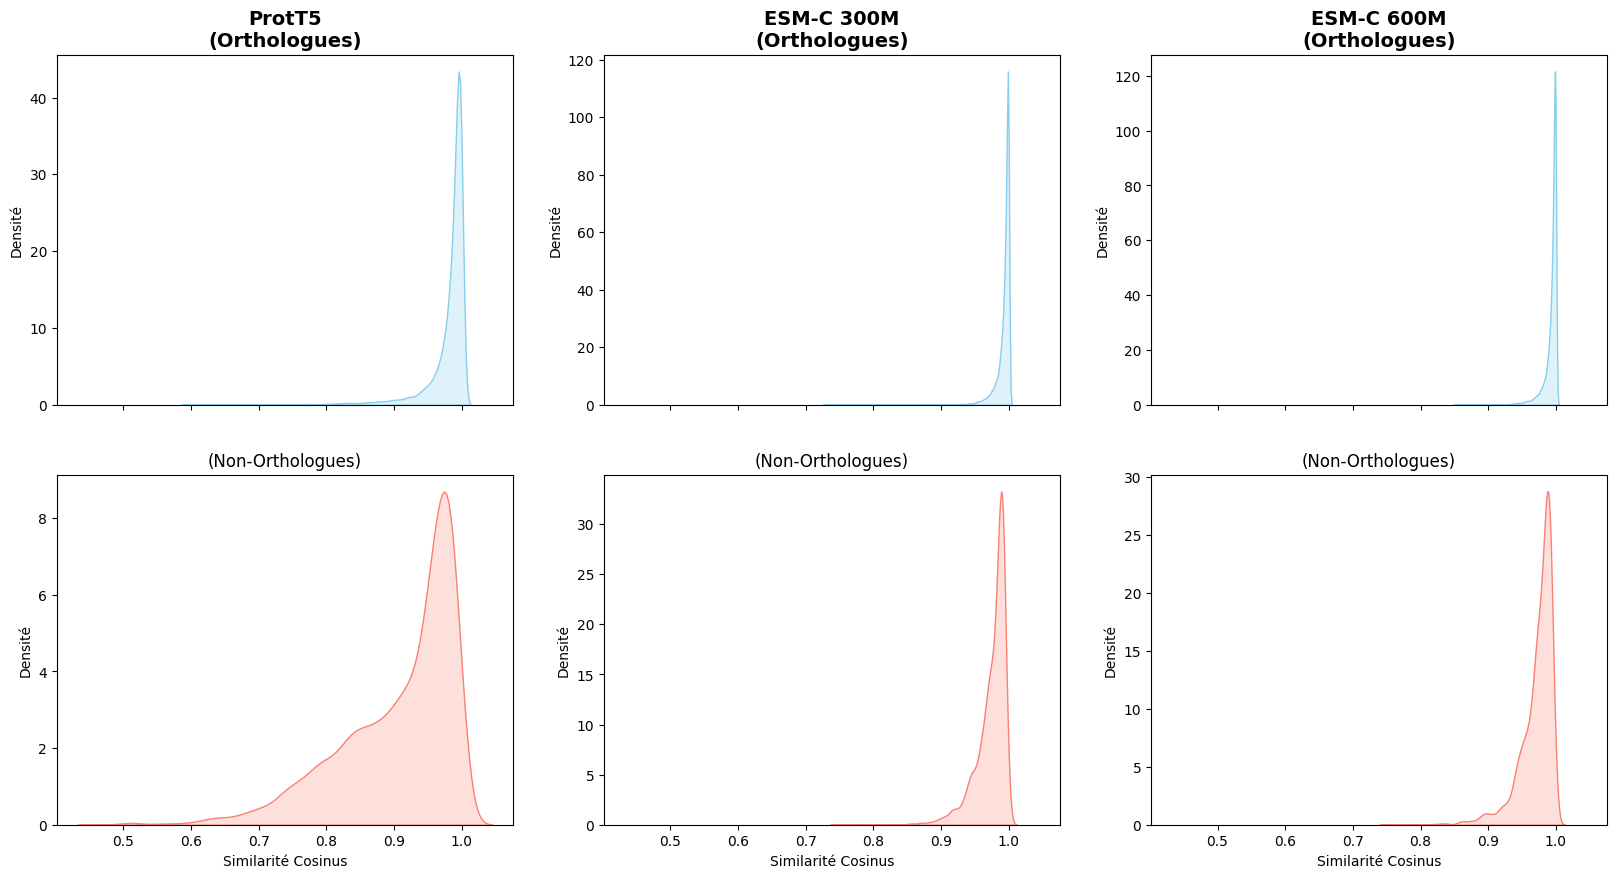

In [27]:

fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True)

models_list = [
    ("ProtT5", final_df_model_A),
    ("ESM-C 300M", final_df_model_B),
    ("ESM-C 600M", final_df_model_C)
]

for i, (name, df) in enumerate(models_list):
    sns.kdeplot(data=df[df['status'] == 'ortho'], x='similarité', 
                fill=True, ax=axes[0, i], color='skyblue', label='Ortho')
    axes[0, i].set_title(f"{name}\n(Orthologues)", fontsize=14, fontweight='bold')
    axes[0, i].set_ylabel("Densité")
    
    sns.kdeplot(data=df[df['status'] == 'non_ortho'], x='similarité', 
                fill=True, ax=axes[1, i], color='salmon', label='Non-Ortho')
    axes[1, i].set_title(f"(Non-Orthologues)", fontsize=12)
    axes[1, i].set_xlabel("Similarité Cosinus")
    axes[1, i].set_ylabel("Densité")


Down there i'll make code to have the full distance matrix and distribution

In [28]:
from scipy.spatial import distance

In [29]:
def normalize_embs(emb):
    return emb / np.linalg.norm(emb, axis=1, keepdims=True)

emb1_a_n = normalize_embs(emb1_a) #
emb2_a_n = normalize_embs(emb2_a)
distancematrix_A = distance.cdist(emb1_a_n, emb2_a_n, metric="cosine")

emb1_b_n = normalize_embs(emb1_b)
emb2_b_n = normalize_embs(emb2_b)
distancematrix_B = distance.cdist(emb1_b_n, emb2_b_n, metric="cosine")

emb1_c_n = normalize_embs(emb1_c)
emb2_c_n = normalize_embs(emb2_c)
distancematrix_C = distance.cdist(emb1_c_n, emb2_c_n, metric="cosine")

#distancematrix_A = distance.cdist(emb1_a, emb2_a, metric="cosine")
#distancematrix_B = distance.cdist(emb1_b, emb2_b, metric="cosine")
#distancematrix_C = distance.cdist(emb1_c, emb2_c, metric="cosine")

In [32]:
#besoin de relier les indices des matrices aux identifiants de la liste obtenues avec embeddings setup + après au liste d'orthologue

def get_indices(id_list,ortho_set,nonortho_set):
    indice_ortho = []
    indice_nonortho = []
    for i, full_id in enumerate(id_list):
        clean_id = full_id.split('|')[1] if '|' in full_id else full_id

        if clean_id in ortho_set:
            indice_ortho.append(i)
        elif clean_id in nonortho_set:
            indice_nonortho.append(i)
    return indice_ortho,indice_nonortho



In [33]:
indice_h_ortho_A,indice_h_nonortho_A = get_indices(id1_a,orgA_fasta_orthologs,orgA_fasta_nonorthologs)
indice_h_ortho_B,indice_h_nonortho_B = get_indices(id1_b,orgA_fasta_orthologs,orgA_fasta_nonorthologs)
indice_h_ortho_C,indice_h_nonortho_C = get_indices(id1_c,orgA_fasta_orthologs,orgA_fasta_nonorthologs)

indice_m_ortho_A,indice_m_nonortho_A = get_indices(id2_a,orgB_fasta_orthologs, orgB_fasta_nonorthologs)
indice_m_ortho_B,indice_m_nonortho_B = get_indices(id2_b,orgB_fasta_orthologs, orgB_fasta_nonorthologs)
indice_m_ortho_C,indice_m_nonortho_C = get_indices(id2_c,orgB_fasta_orthologs, orgB_fasta_nonorthologs)

In [34]:


models = [
    ('ProtT5 (A)', distancematrix_A, indice_h_ortho_A, indice_h_nonortho_A, indice_m_ortho_A, indice_m_nonortho_A),
    ('ESMC-300 (B)', distancematrix_B, indice_h_ortho_B, indice_h_nonortho_B, indice_m_ortho_B, indice_m_nonortho_B),
    ('ESMC-600 (C)', distancematrix_C, indice_h_ortho_C, indice_h_nonortho_C, indice_m_ortho_C, indice_m_nonortho_C)]

resultat_distance = {}

for name, matrix, h_o, h_no, m_o, m_no in models:
    dist_h_ortho = matrix[h_o, :].flatten()
    dist_h_nonortho = matrix[h_no, :].flatten()

    dist_m_ortho = matrix[:, m_o].flatten()
    dist_m_nonortho = matrix[:, m_no].flatten()

    resultat_distance[name] = {
        'h_ortho': dist_h_ortho,
        'h_nonortho': dist_h_nonortho,
        'm_ortho': dist_m_ortho,
        'm_nonortho': dist_m_nonortho}    



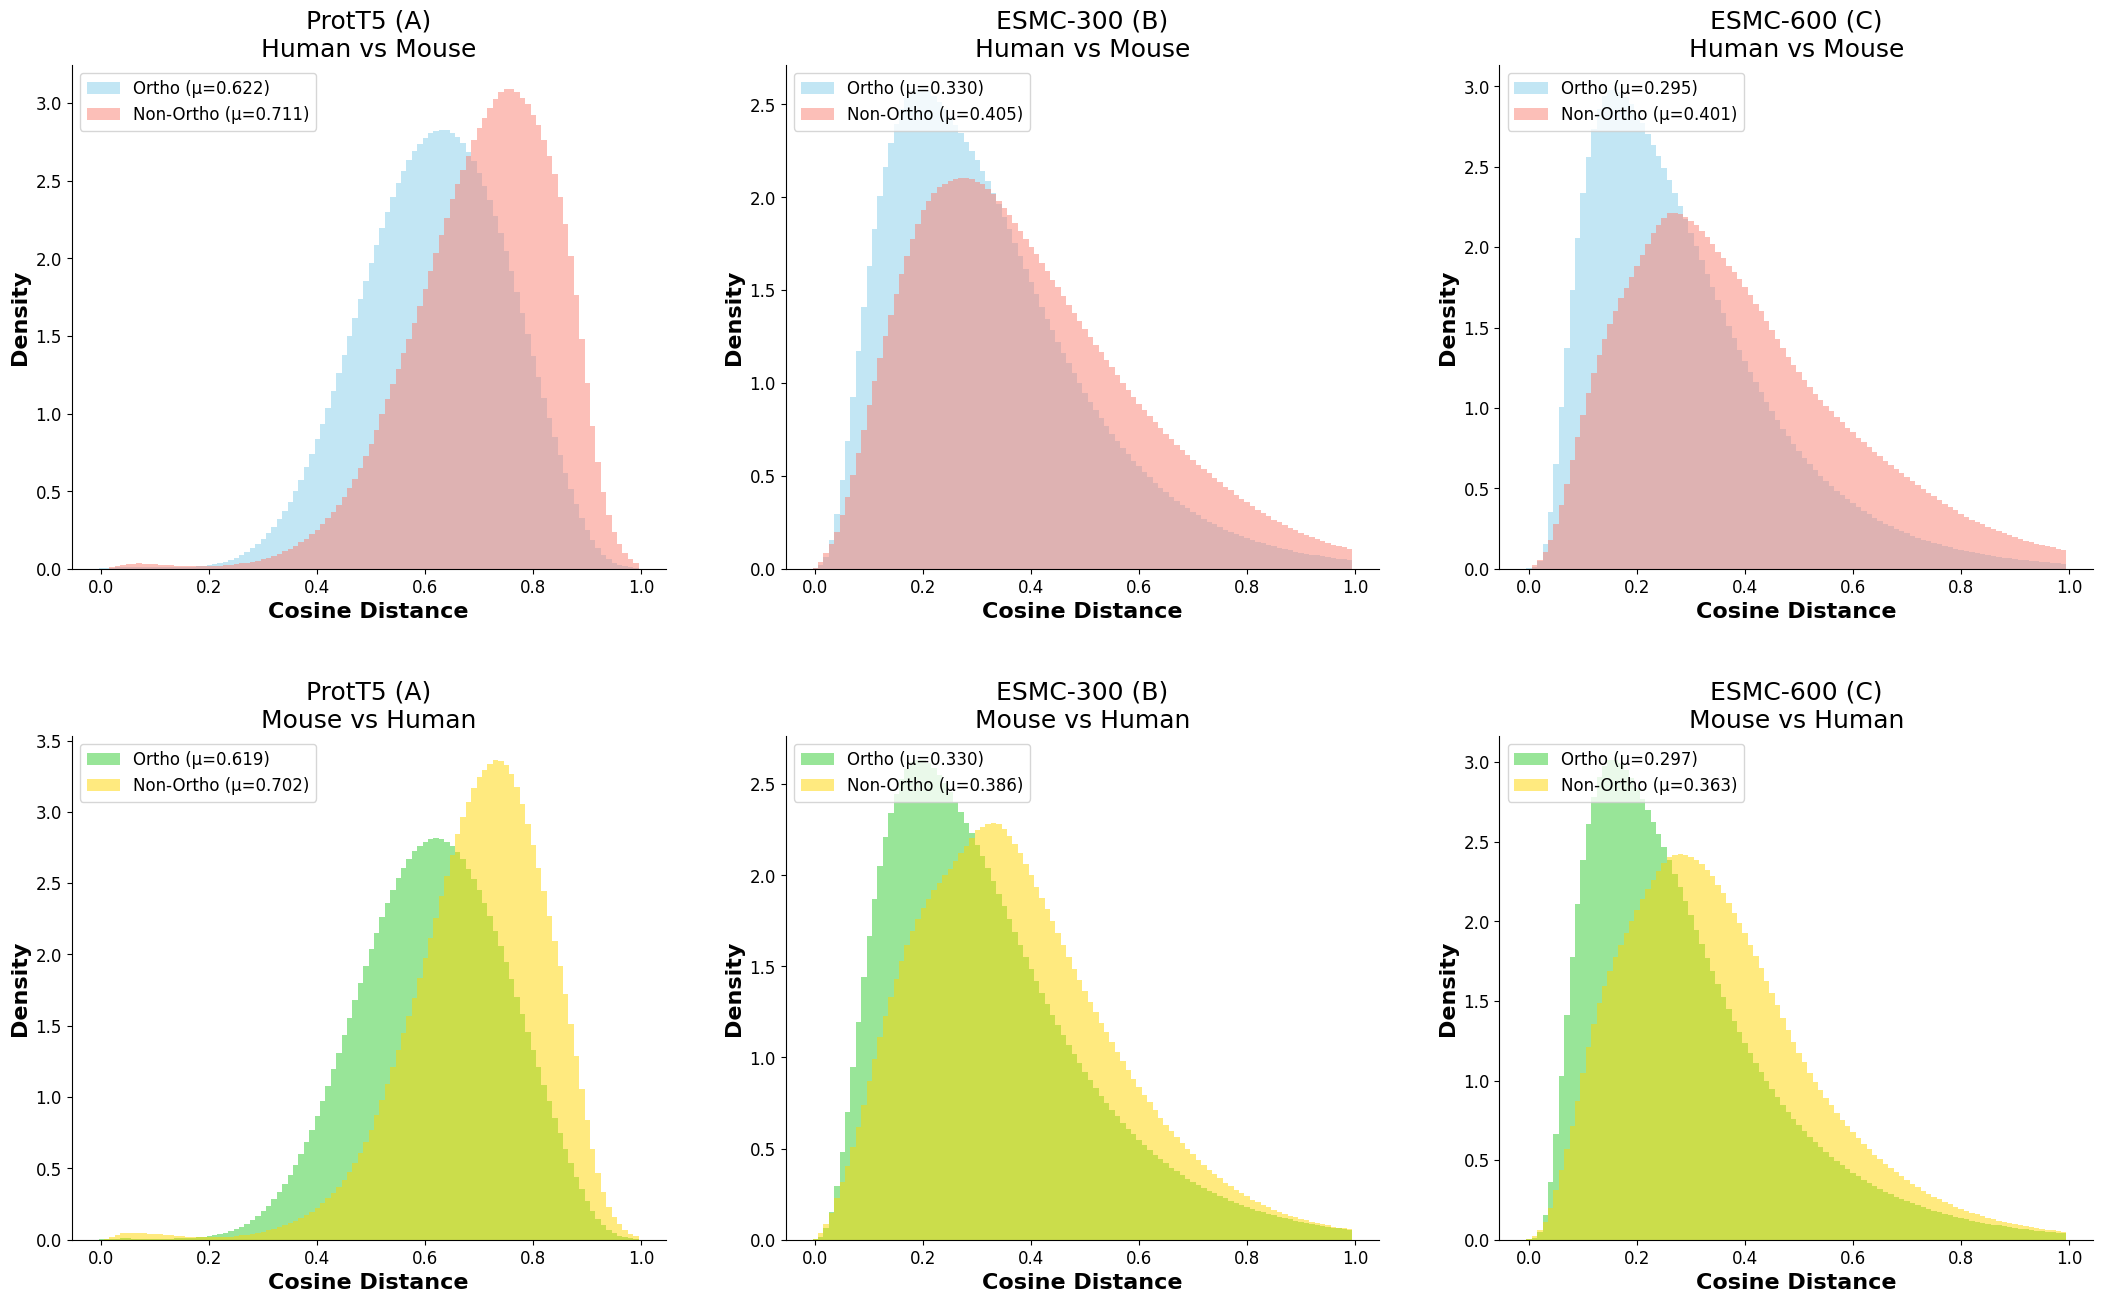

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SET GLOBAL FONT SIZES ---
plt.rcParams.update({
    'font.size': 14,          # General font size
    'axes.titlesize': 18,     # Title of each subplot
    'axes.labelsize': 16,     # X and Y axis labels
    'xtick.labelsize': 12,    # X tick numbers
    'ytick.labelsize': 12,    # Y tick numbers
    'legend.fontsize': 12,    # Legend text
    'figure.titlesize': 22    # Overall figure title (if used)
})

fig, axes = plt.subplots(2, 3, figsize=(22, 14), sharex=False) # Slightly wider for better spacing
model_names = ['ProtT5 (A)', 'ESMC-300 (B)', 'ESMC-600 (C)']
nb_bins = np.linspace(0, 1, 101)

for i, name in enumerate(model_names):
    data = resultat_distance[name]
    
    # --- Human vs Mouse ---
    h_ortho_hist, _ = np.histogram(data['h_ortho'], bins=nb_bins, density=True)
    h_no_hist, _ = np.histogram(data['h_nonortho'], bins=nb_bins, density=True)
    
    axes[0, i].bar(nb_bins[:-1], h_ortho_hist, width=np.diff(nb_bins), alpha=0.5, 
                   label=f"Ortho (µ={np.mean(data['h_ortho']):.3f})", color="skyblue")
    axes[0, i].bar(nb_bins[:-1], h_no_hist, width=np.diff(nb_bins), alpha=0.5, 
                   label=f"Non-Ortho (µ={np.mean(data['h_nonortho']):.3f})", color="salmon")
    axes[0, i].set_title(f"{name}\nHuman vs Mouse")

    # --- Mouse vs Human ---
    m_ortho_hist, _ = np.histogram(data['m_ortho'], bins=nb_bins, density=True)
    m_no_hist, _ = np.histogram(data['m_nonortho'], bins=nb_bins, density=True)
    
    axes[1, i].bar(nb_bins[:-1], m_ortho_hist, width=np.diff(nb_bins), alpha=0.5, 
                   label=f"Ortho (µ={np.mean(data['m_ortho']):.3f})", color="limegreen")
    axes[1, i].bar(nb_bins[:-1], m_no_hist, width=np.diff(nb_bins), alpha=0.5, 
                   label=f"Non-Ortho (µ={np.mean(data['m_nonortho']):.3f})", color="gold")
    axes[1, i].set_title(f"{name}\nMouse vs Human")

# --- 2. GLOBAL FORMATTING ---
for ax in axes.flat:
    ax.set_xlabel("Cosine Distance", fontweight='bold')
    ax.set_ylabel("Density", fontweight='bold')
    ax.legend(loc='upper left', frameon=True)
    # Clean up the look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(pad=3.0) # More padding to prevent text overlap

# --- 3. EXPORT ---
plt.savefig("large_font_histograms.png", dpi=300, bbox_inches='tight') 
# Using PNG with 300 DPI is safer for most PowerPoint versions, but switch to .svg if you prefer!
plt.show()

In [31]:
"""from scipy.stats import mannwhitneyu


alpha = 0.05 

for name in model_names:
    data = resultat_distance[name]

    stat_orgA, p_orgA = mannwhitneyu(data['h_nonortho'], data['h_ortho'], alternative='greater')
    stat_orgB, p_orgB = mannwhitneyu(data['m_nonortho'], data['m_ortho'], alternative='greater')

    valide_A = "VRAI" if p_orgA < alpha else "FAUX"
    valide_B = "VRAI" if p_orgB < alpha else "FAUX""""

    


SyntaxError: unterminated string literal (detected at line 13) (4123750128.py, line 13)

In [32]:
print(f"[{name}]")
print(f"  Humain vs Organisme B : p={p_orgA} -> Hypothèse = {valide_A}")
print(f"  Organisme B vs Humain  : p={p_orgB} -> Hypothèse = {valide_B}")

[ESMC-600 (C)]


NameError: name 'p_orgA' is not defined

Now need code to rank the distances matrix and see the orthologs :
- 

In [37]:
def clean_id(long_id):
    if '|' in long_id:
        return long_id.split('|')[1]
    return long_id

#get my id list clean and give them their rank so i know where to work in the matrix

h_map_A = {clean_id(pid): i for i, pid in enumerate(id1_a)}
y_map_A = {clean_id(pid): i for i, pid in enumerate(id2_a)}

h_map_B = {clean_id(pid): i for i, pid in enumerate(id1_b)}
y_map_B = {clean_id(pid): i for i, pid in enumerate(id2_b)}

h_map_C = {clean_id(pid): i for i, pid in enumerate(id1_c)}
y_map_C = {clean_id(pid): i for i, pid in enumerate(id2_c)}


Down there i'll make code to have the full distance matrix and distribution

Now need code to rank the distances matrix and see the orthologs :
- 

In [38]:

pairs_path = '/home/cassandre/stage/Cassandre/ortho/liste_orthologs/MOUSE_HUMAN.tsv'

#storage 
list_rankA = {}
list_rankB = {}
list_rankC = {}

with open(pairs_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            h_id, y_id = parts[0], parts[1]
            
            if h_id in h_map_A and y_id in y_map_A:
                dist = distancematrix_A[h_map_A[h_id], y_map_A[y_id]]
                rank = (distancematrix_A[h_map_A[h_id], :] < dist).sum() + 1
                list_rankA.setdefault(h_id, []).append(rank)

            if h_id in h_map_B and y_id in y_map_B:
                dist = distancematrix_B[h_map_B[h_id], y_map_B[y_id]]
                rank = (distancematrix_B[h_map_B[h_id], :] < dist).sum() + 1
                list_rankB.setdefault(h_id, []).append(rank)

            if h_id in h_map_C and y_id in y_map_C:
                dist = distancematrix_C[h_map_C[h_id], y_map_C[y_id]]
                rank = (distancematrix_C[h_map_C[h_id], :] < dist).sum() + 1
                list_rankC.setdefault(h_id, []).append(rank)



In [39]:
print(f"{'HUMAN ID':<15} | {'PROTT5 (A)':<18} | {'ESMC-300 (B)':<18} | {'ESMC-600 (C)'}")
print("-" * 75)

for h_id in list_rankA.keys():
    ranks_A = list_rankA[h_id]
    ranks_B = list_rankB[h_id]
    ranks_C = list_rankC[h_id]
    
    print(f"{h_id:<15} | {str(ranks_A):<18} | {str(ranks_B):<18} | {str(ranks_C)}")

HUMAN ID        | PROTT5 (A)         | ESMC-300 (B)       | ESMC-600 (C)
---------------------------------------------------------------------------
Q9UPV9          | [1]                | [1]                | [1]
Q9UPW0          | [1]                | [1]                | [1]
Q9UPW5          | [1]                | [1]                | [1]
Q9UPW6          | [1]                | [1]                | [1]
Q9UPW8          | [1]                | [1]                | [1]
Q9UPX0          | [1]                | [1]                | [1]
Q9UPX6          | [1]                | [1]                | [1]
Q9UPX8          | [1]                | [6]                | [2]
Q9UPY3          | [1]                | [1]                | [1]
Q9UPY5          | [1]                | [1]                | [1]
Q9UPY6          | [1]                | [1]                | [1]
Q9UPY8          | [1]                | [1]                | [1]
Q9UPZ3          | [1]                | [1]                | [1]
Q9UPZ6          | [

In [40]:
paires_temp = []
inventaire_humain = {}
inventaire_souris = {}

with open(pairs_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            h_id, m_id = parts[0], parts[1]
            paires_temp.append((h_id, m_id))
            
            inventaire_humain[h_id] = inventaire_humain.get(h_id, 0) + 1
            inventaire_souris[m_id] = inventaire_souris.get(m_id, 0) + 1


In [41]:
def get_orthology_results(matrix, h_map, y_map, paires, inv_h, inv_m):
    raw_results = {'All': [], 'OtO': [], 'OtM': [], 'MtO': [], 'MtM': []}

    for h_id, m_id in paires:
        if h_id in h_map and m_id in y_map:
            dist = matrix[h_map[h_id], y_map[m_id]]
            rank = (matrix[h_map[h_id], :] < dist).sum() + 1
            K = inv_h[h_id] 
            
            res = (rank, K, h_id, m_id)
            raw_results['All'].append(res)
            
            if inv_h[h_id] == 1 and inv_m[m_id] == 1:
                raw_results['OtO'].append(res)
            elif inv_h[h_id] > 1 and inv_m[m_id] == 1:
                raw_results['OtM'].append(res)
            elif inv_h[h_id] == 1 and inv_m[m_id] > 1:
                raw_results['MtO'].append(res)
            else:
                raw_results['MtM'].append(res)

    stats = {}
    
    for cat, r_list in raw_results.items():
        if len(r_list) > 0:
            ranks_only = [r[0] for r in r_list]
            stats[cat] = (np.mean(ranks_only), np.median(ranks_only))
        else:
            stats[cat] = (0.0, 0.0)
    
    return stats, raw_results

In [42]:
stats_A, raw_A = get_orthology_results(distancematrix_A, h_map_A, y_map_A, paires_temp, inventaire_humain, inventaire_souris)
stats_B, raw_B = get_orthology_results(distancematrix_B, h_map_B, y_map_B, paires_temp, inventaire_humain, inventaire_souris)
stats_C, raw_C = get_orthology_results(distancematrix_C, h_map_C, y_map_C, paires_temp, inventaire_humain, inventaire_souris)

models = [("Model A", stats_A), ("Model B", stats_B), ("Model C", stats_C)]

print(f"{'Category':<15} | {'Metric':<8} | {'Model A':<10} | {'Model B':<10} | {'Model C':<10}")
print("-" * 75)

for category in ['All', 'OtO', 'OtM', 'MtO', 'MtM']:
    avg_line = f"{category:<15} | {'Average':<8}"
    med_line = f"{'':<15} | {'Median':<8}"
    
    for name, stat in models:
        avg_line += f" | {stat[category][0]:<10.2f}"
        med_line += f" | {stat[category][1]:<10.2f}"
    
    print(avg_line)
    print(med_line)
    print("-" * 75)

Category        | Metric   | Model A    | Model B    | Model C   
---------------------------------------------------------------------------
All             | Average  | 12.40      | 48.72      | 44.86     
                | Median   | 1.00       | 1.00       | 1.00      
---------------------------------------------------------------------------
OtO             | Average  | 9.31       | 29.56      | 31.36     
                | Median   | 1.00       | 1.00       | 1.00      
---------------------------------------------------------------------------
OtM             | Average  | 49.74      | 67.94      | 62.38     
                | Median   | 2.00       | 3.00       | 3.00      
---------------------------------------------------------------------------
MtO             | Average  | 26.71      | 132.20     | 213.24    
                | Median   | 1.00       | 1.00       | 1.00      
---------------------------------------------------------------------------
MtM             | Average 

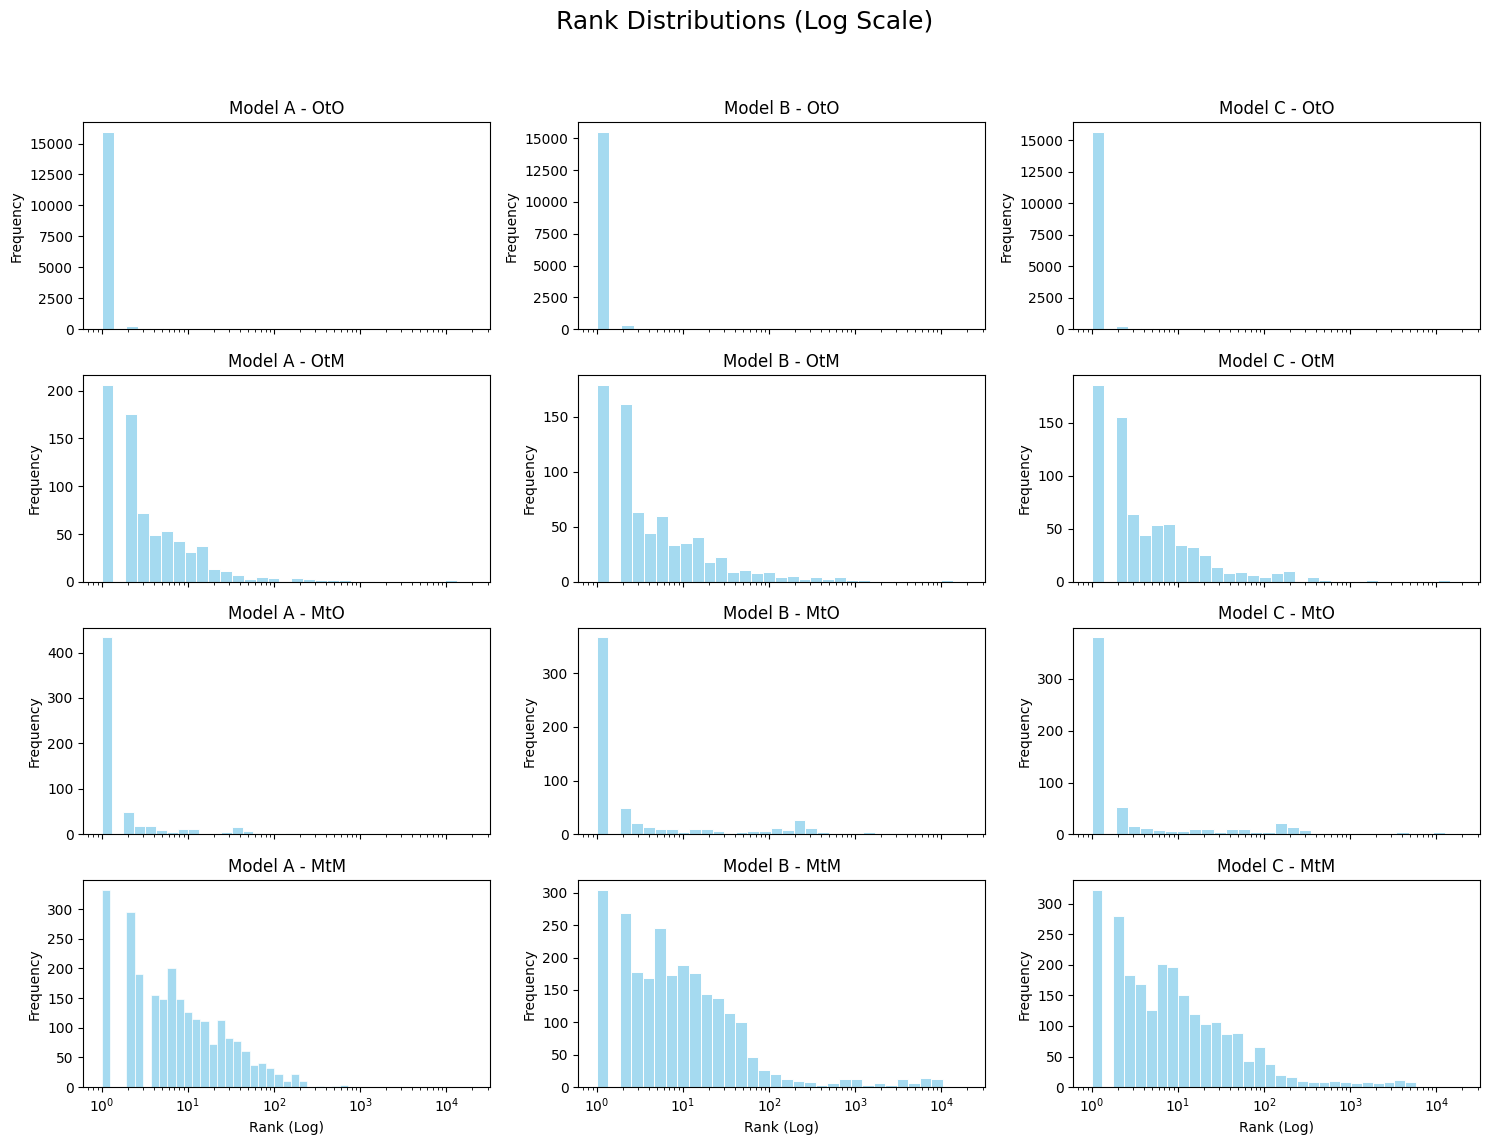

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

list_models = [("Model A", raw_A), ("Model B", raw_B), ("Model C", raw_C)]
categories = ['OtO', 'OtM', 'MtO', 'MtM']

fig, axes = plt.subplots(len(categories), len(list_models), figsize=(15, 12), sharex=True)
fig.suptitle("Rank Distributions (Log Scale)", fontsize=18)

for row_idx, cat in enumerate(categories):
    for col_idx, (name, raw_data_dict) in enumerate(list_models):
        ax = axes[row_idx, col_idx]
        
        # raw_data_dict[cat] contains tuples (rank, K, h_id, m_id)
        # We only want the rank (the first element of the tuple)
        if cat in raw_data_dict and raw_data_dict[cat]:
            data = [item[0] for item in raw_data_dict[cat]] 
            
            sns.histplot(data, bins=30, ax=ax, log_scale=True, color="skyblue", edgecolor="white")
            ax.set_title(f"{name} - {cat}")
            ax.set_xlabel("Rank (Log)")
            ax.set_ylabel("Frequency")
        else:
            ax.text(0.5, 0.5, f"No Data for {cat}", ha='center', va='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

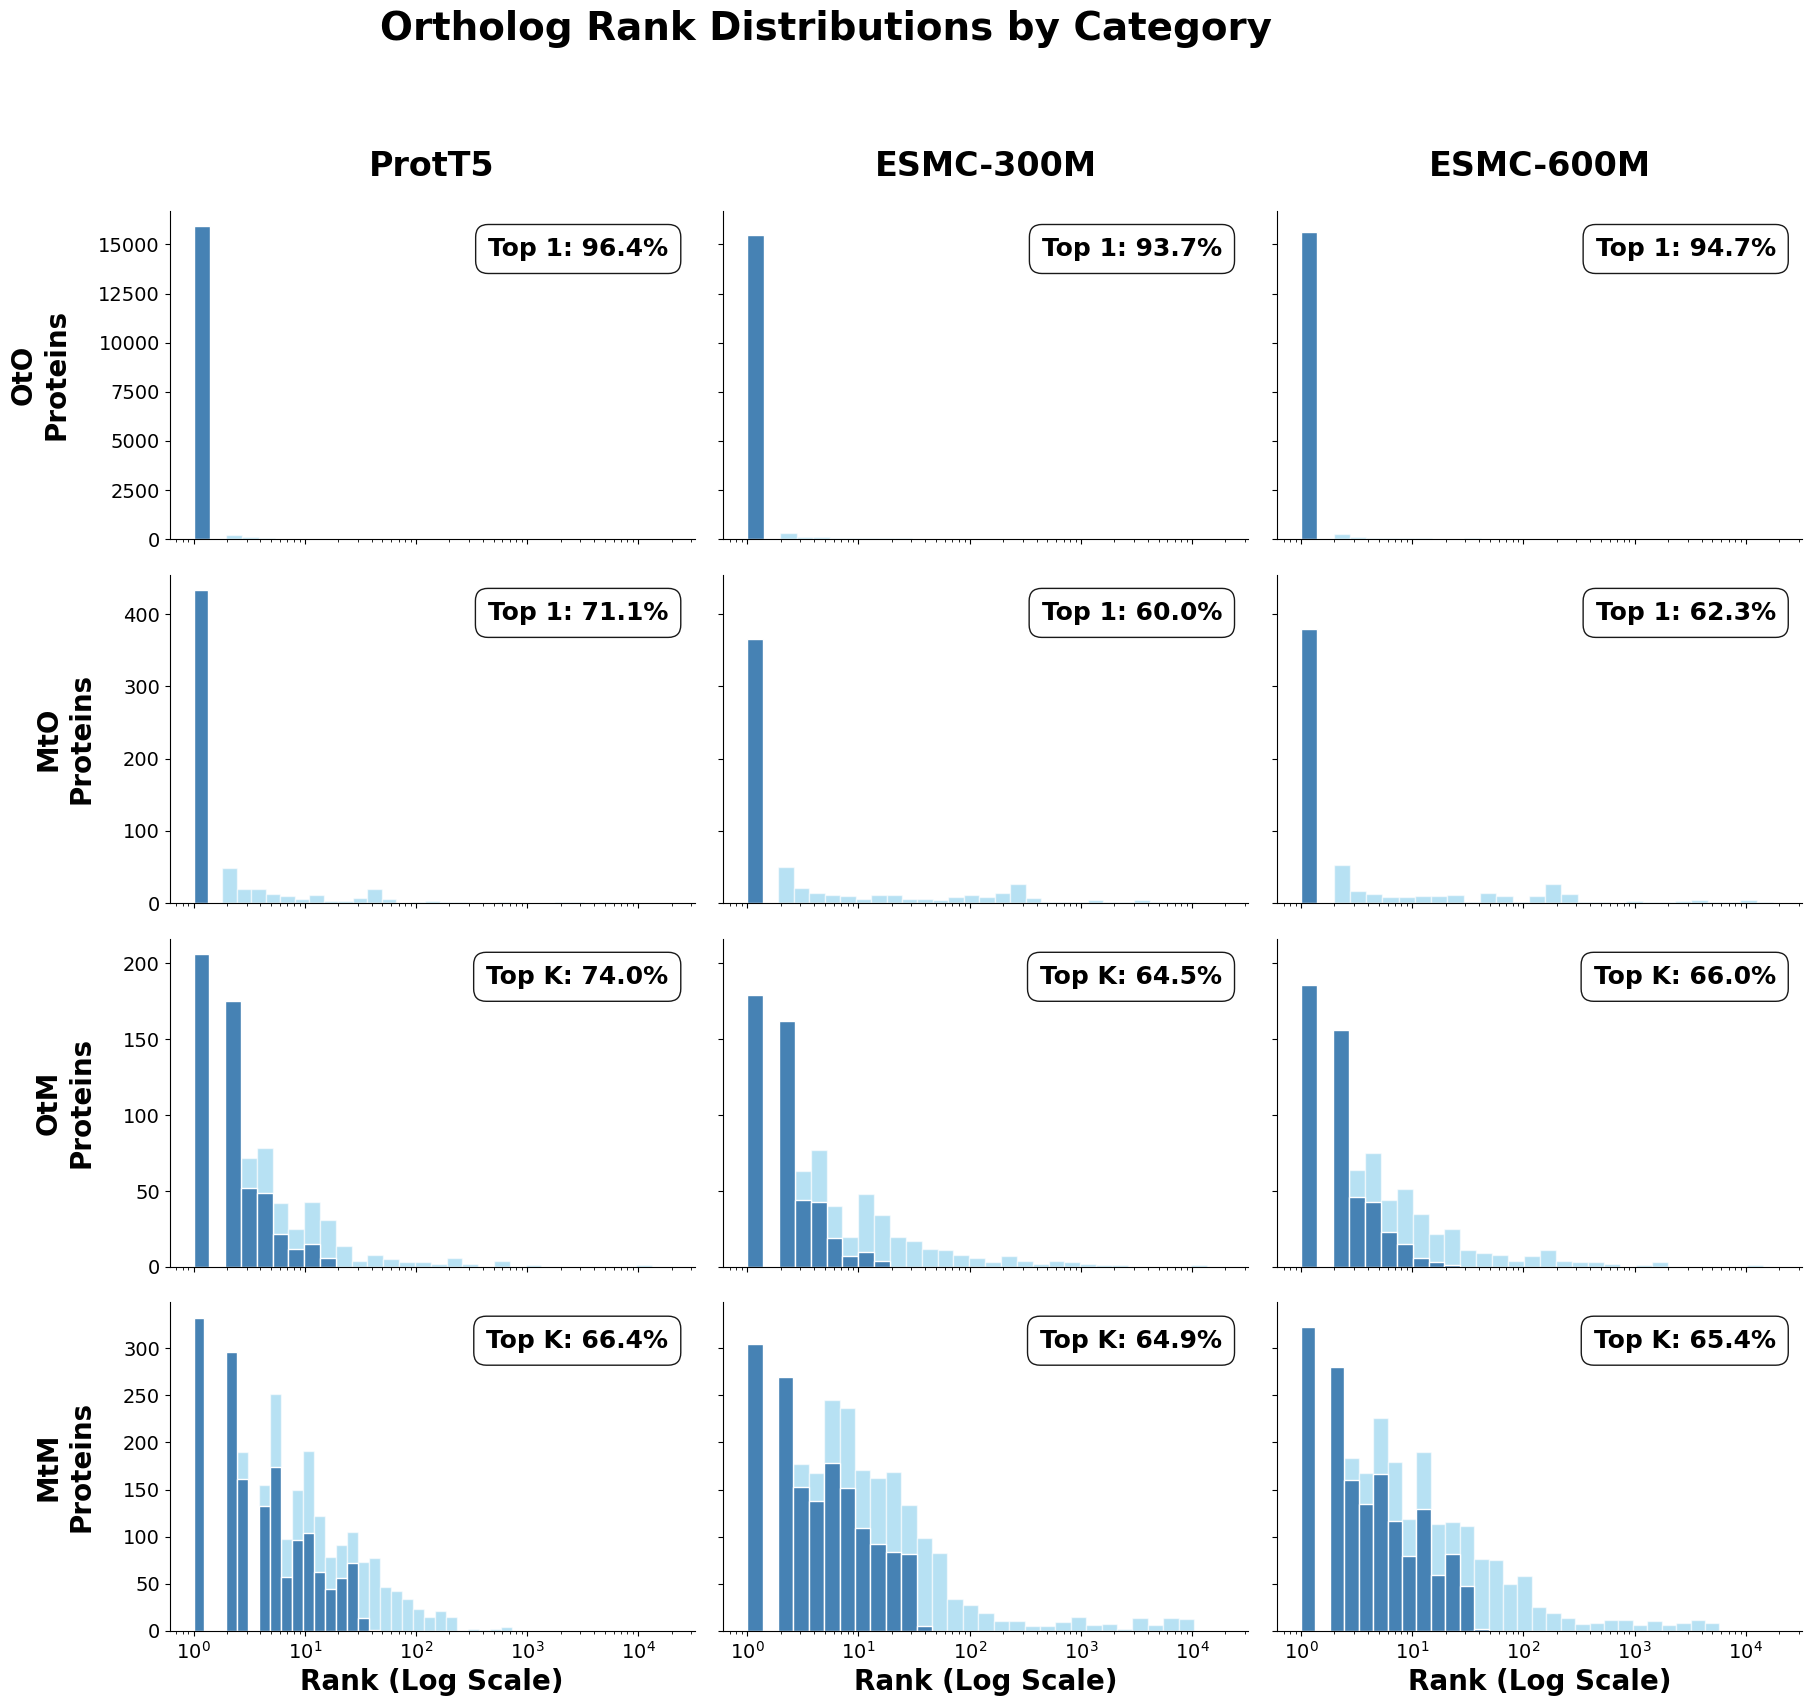

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. SET AGGRESSIVE GLOBAL FONT SIZES ---
plt.rcParams.update({
    'font.size': 16,            # General base size
    'axes.titlesize': 22,       # Model names (Top row)
    'axes.labelsize': 20,       # X/Y labels
    'xtick.labelsize': 14,      # Tick numbers
    'ytick.labelsize': 14,      # Tick numbers
    'legend.fontsize': 16
})

categories = ['OtO', 'MtO', 'OtM', 'MtM'] 
list_models = [("ProtT5", raw_A), ("ESMC-300M", raw_B), ("ESMC-600M", raw_C)]

# Increased figsize to handle larger text without overlap
fig, axes = plt.subplots(len(categories), len(list_models), figsize=(20, 18), 
                         sharex=True, sharey='row')
fig.suptitle("Ortholog Rank Distributions by Category", fontsize=28, y=0.98, fontweight='bold')

COLOR_SUCCESS = "steelblue"
COLOR_OTHER = "skyblue"

for row_idx, cat in enumerate(categories):
    for col_idx, (name, raw_data_dict) in enumerate(list_models):
        ax = axes[row_idx, col_idx]
        
        if cat in raw_data_dict and raw_data_dict[cat]:
            ranks = np.array([float(item[0]) for item in raw_data_dict[cat]])
            k_vals = np.array([float(item[1]) for item in raw_data_dict[cat]])
            
            if cat in ['OtO', 'MtO']:
                is_success = ranks == 1
                metric_label = "Top 1"
            else:
                is_success = ranks <= k_vals
                metric_label = "Top K"
                
            perc_success = (np.sum(is_success) / len(ranks)) * 100
            bins = np.logspace(0, np.log10(max(ranks) if max(ranks) > 1 else 10), 30)
            
            ax.hist(ranks, bins=bins, color=COLOR_OTHER, edgecolor="white", alpha=0.6)
            success_ranks = ranks[is_success]
            if len(success_ranks) > 0:
                ax.hist(success_ranks, bins=bins, color=COLOR_SUCCESS, edgecolor="white")

            ax.set_xscale('log')

            # --- 2. TITLES & LABELS (FORCED LARGER) ---
            if row_idx == 0:
                ax.set_title(name, fontsize=24, fontweight='bold', pad=25)
            
            if col_idx == 0:
                # Category labels on the side
                ax.set_ylabel(f"{cat}\nProteins", fontsize=20, fontweight='bold', labelpad=20)
            
            if row_idx == len(categories) - 1:
                ax.set_xlabel("Rank (Log Scale)", fontsize=20, fontweight='bold')

            # --- 3. THE "BIG" PERCENTAGE BOX ---
            # Fontsize set to 18 and Bold for the jury
            stats_text = f"{metric_label}: {perc_success:.1f}%"
            ax.text(0.95, 0.92, stats_text, transform=ax.transAxes, 
                    fontsize=18, fontweight='bold', # <--- BIG & BOLD
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black'))
            
            # Remove spines for a cleaner look
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
        else:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=20)

# Adjust layout to accommodate the larger labels
plt.tight_layout(rect=[0.08, 0.03, 1, 0.95])

# --- 4. EXPORT FOR SLIDES ---
plt.savefig("rank_distributions_large.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#For one to one, calculate the % of pairs that have the orthologs as  top1, top5, top10

print(f"{'MODÈLE':<9} | {'TOP 1':>10} | {'TOP 5':>10} | {'TOP 10':>10} | {'TOP 100':>10}")
print("-" * 65)

for name, raw_data in [("Model A", raw_A), ("Model B", raw_B), ("Model C", raw_C)]:
    

    oto_ranks = [r[0] for r in raw_data['OtO']]
    
    if not oto_ranks:
        print(f"{name:<9} | No OtO data found")
        continue
        
    data = np.array(oto_ranks)
    
    top1 = (data <= 1).mean() * 100
    top5 = (data <= 5).mean() * 100
    top10 = (data <= 10).mean() * 100
    top100 = (data <= 100).mean() * 100
    
    print(f"{name:<9} | {top1:>9.2f}% | {top5:>9.2f}% | {top10:>9.2f}% | {top100:>9.2f}%")

MODÈLE    |      TOP 1 |      TOP 5 |     TOP 10 |    TOP 100
-----------------------------------------------------------------
Model A   |     96.43% |     98.64% |     98.98% |     99.57%
Model B   |     93.71% |     96.93% |     97.53% |     98.91%
Model C   |     94.66% |     97.46% |     97.98% |     99.01%


In [45]:

nb_totale_protsouris= distancematrix_A.shape[1]
ten_percent_threshold = nb_totale_protsouris * 0.01

models_top = [("Model A", distancematrix_A, h_map_A, y_map_A),("Model B", distancematrix_B, h_map_B, y_map_B),("Model C", distancematrix_C, h_map_C, y_map_C)]

for name, raw_data in [("Model A", raw_A), ("Model B", raw_B), ("Model C", raw_C)]:
    otm_pairs = raw_data['OtM']

    count_topk = 0
    count_topk10 = 0
    count_top10percent = 0
    count_topk100 = 0
    total = len(otm_pairs)
    
    for r in otm_pairs:
        rang = r[0]
        K = r[1]

        if rang <= K:
            count_topk +=1

        if rang <= K+10:
            count_topk10 +=1
        
        if rang <= ten_percent_threshold:
            count_top10percent +=1
        
        if rang <= 100:
            count_topk100 +=1


    percentk = (count_topk / total)*100
    percentk10 = (count_topk10 / total)*100
    percent10perc =(count_top10percent / total)*100
    percent100 = (count_topk100 / total)*100

    print(f"{name:<12} | {percentk:>9.2f}% | {percentk10:>11.2f}% | {percent10perc:>11.2f}% | {percent100:>11.2f}%")



Model A      |     73.97% |       91.05% |       98.35% |       97.25%
Model B      |     64.46% |       83.75% |       96.97% |       95.18%
Model C      |     65.98% |       85.12% |       97.93% |       94.90%


In [53]:

print(f"{'MODÈLE':<9} | {'TOP 1':>10} | {'TOP 5':>10} | {'TOP 10':>10} | {'TOP 100':>10}")
print("-" * 65)

for name, raw_data in [("Model A", raw_A), ("Model B", raw_B), ("Model C", raw_C)]:
    

    oto_ranks = [r[0] for r in raw_data['MtO']]
    
    if not oto_ranks:
        print(f"{name:<9} | No MtO data found")
        continue
        
    data = np.array(oto_ranks)
    
    top1 = (data <= 1).mean() * 100
    top5 = (data <= 5).mean() * 100
    top10 = (data <= 10).mean() * 100
    top100 = (data <= 100).mean() * 100
    
    print(f"{name:<9} | {top1:>9.2f}% | {top5:>9.2f}% | {top10:>9.2f}% | {top100:>9.2f}%")

MODÈLE    |      TOP 1 |      TOP 5 |     TOP 10 |    TOP 100
-----------------------------------------------------------------
Model A   |     71.10% |     87.03% |     89.82% |     98.03%
Model B   |     60.00% |     75.08% |     77.54% |     86.39%
Model C   |     62.30% |     75.74% |     78.52% |     88.03%


In [54]:

nb_totale_protsouris= distancematrix_A.shape[1]
ten_percent_threshold = nb_totale_protsouris * 0.01

models_top = [("Model A", distancematrix_A, h_map_A, y_map_A),("Model B", distancematrix_B, h_map_B, y_map_B),("Model C", distancematrix_C, h_map_C, y_map_C)]

for name, raw_data in [("Model A", raw_A), ("Model B", raw_B), ("Model C", raw_C)]:
    otm_pairs = raw_data['MtM']

    count_topk = 0
    count_topk10 = 0
    count_top10percent = 0
    count_topk100 = 0
    total = len(otm_pairs)
    
    for r in otm_pairs:
        rang = r[0]
        K = r[1]

        if rang <= K:
            count_topk +=1

        if rang <= K+10:
            count_topk10 +=1
        
        if rang <= ten_percent_threshold:
            count_top10percent +=1
        
        if rang <= 100:
            count_topk100 +=1


    percentk = (count_topk / total)*100
    percentk10 = (count_topk10 / total)*100
    percent10perc =(count_top10percent / total)*100
    percent100 = (count_topk100 / total)*100

    print(f"{name:<12} | {percentk:>9.2f}% | {percentk10:>11.2f}% | {percent10perc:>11.2f}% | {percent100:>11.2f}%")



Model A      |     66.39% |       83.88% |       99.59% |       96.81%
Model B      |     64.90% |       79.53% |       95.61% |       93.87%
Model C      |     65.44% |       79.07% |       95.73% |       92.87%


In [55]:
#check if the orthologs are right 

import random

def get_verification_examples(raw_results, num_examples=2):
    categories = ['OtO', 'OtM', 'MtO', 'MtM']
    
    print(f"{'Cat':<5} | {'Human ID':<12} | {'Mouse ID':<12} | {'K (H->M)':<3} | {'Rank'}")
    print("-" * 50)
    
    for cat in categories:
        samples = raw_results[cat]
        if len(samples) > 0:
            # Pick random samples to avoid bias
            chosen = random.sample(samples, min(num_examples, len(samples)))
            for rank, K, h_id, m_id in chosen:
                print(f"{cat:<5} | {h_id:<12} | {m_id:<12} | {K:<3} | {rank}")

# Usage:
get_verification_examples(raw_A)

Cat   | Human ID     | Mouse ID     | K (H->M) | Rank
--------------------------------------------------
OtO   | Q5TZF3       | Q810N6       | 1   | 1
OtO   | P82279       | Q8VHS2       | 1   | 1
OtM   | P01615       | A0A0B4J1H6   | 2   | 12
OtM   | Q8NH51       | Q7TR67       | 10  | 4
MtO   | P0C862       | Q4ZJN1       | 1   | 1
MtO   | A3QJZ7       | Q9D2F1       | 1   | 1
MtM   | P04439       | G3UXE9       | 12  | 10
MtM   | P43364       | Q6T340       | 8   | 7


In [58]:
def get_failures_ids(raw_data):
    failure_lists = {
        'OtO_human_fail': set(), 'OtO_mouse_fail': set(),
        'MtO_human_fail': set(), 'MtO_mouse_fail': set(),
        'OtM_human_fail': set(), 'OtM_mouse_fail': set(),
        'MtM_human_fail': set(), 'MtM_mouse_fail': set()
    }
    
    categories = ['OtO', 'MtO', 'OtM', 'MtM']
    
    for cat in categories:
        for rank, K, h_id, m_id in raw_data[cat]:
            if cat in ['OtO', 'MtO']:
                failed = (rank > 1)
            else:
                failed = (rank > K)
            
            if failed:
                failure_lists[f"{cat}_human_fail"].add(h_id)
                failure_lists[f"{cat}_mouse_fail"].add(m_id)
                
    return {k: sorted(list(v)) for k, v in failure_lists.items()}

strict_failuresA = get_failures_ids(raw_A)
strict_failuresB = get_failures_ids(raw_B)
strict_failuresC = get_failures_ids(raw_C)


In [1]:
#print list of oto

In [31]:

mapping_path = "/home/cassandre/stage/Cassandre/ortho/comparison_results/human_yeast/ESM600M_full_results.tsv"
df = pd.read_csv(mapping_path, sep='\t')

categories = ['OtO', 'OtM', 'MtO', 'MtM']

for cat in categories:
    filtered_df = df[df['Category'] == cat]
    
    bg_ids = filtered_df['Org2_ID'].unique().tolist()
    
    bg_filename = f"background_yeast_h_ESM600M_{cat.lower()}.txt"
    bg_full_path = os.path.join(os.path.dirname(mapping_path), bg_filename)
    
    with open(bg_full_path, 'w') as f:
        for m_id in bg_ids:
            f.write(f"{m_id}\n")


In [ ]:
mouse_outliers = "/home/cassandre/stage/Cassandre/panthr_text/human_mouse/human_mouseoutliers_mus.txt"
human_outliers = "/home/cassandre/stage/Cassandre/panthr_text/human_mouse/human_mouseoutliers_homosapiens.txt"

In [ ]:
import pandas as pd
from scipy.stats import fisher_exact

outlier_files = {
    "ProtT5": {
        "Human": "/home/cassandre/stage/Cassandre/ortho/outliers/human_mus_protT5/human_mouseoutliers_homosapiens.txt",
        "Mouse": "/home/cassandre/stage/Cassandre/ortho/outliers/human_mus_protT5/human_mouseoutliers_mus.txt"
    },
    "ESMC-300M": {
        "Human": "/home/cassandre/stage/Cassandre/ortho/outliers/esmc_outliers_homosapiens.txt",
        "Mouse": "/home/cassandre/stage/Cassandre/ortho/outliers/esmc_outliers_mus.txt"
    },
    "ESMC-600M": {
        "Human": "/home/cassandre/stage/Cassandre/ortho/outliers/esmc600Moutliers_homosapiens.txt",
        "Mouse": "/home/cassandre/stage/Cassandre/ortho/outliers/esmc600Moutliers_mus.txt"
    }
}

def load_outlier_set(path):
    outliers = set()
    try:
        with open(path, 'r') as f:
            for line in f:
                clean_id = line.strip()
                if clean_id: outliers.add(clean_id)
    except FileNotFoundError:
        return None
    return outliers

def perform_enrichment_analysis(df_model, model_name, outlier_paths, ortho_sets):
    results = []
    
    for species in ["Human", "Mouse"]:
        outlier_set = load_outlier_set(outlier_paths[model_name][species])
        if outlier_set is None: continue
            
        df_sp = df_model[df_model['species'] == species].copy()
        df_sp['pid_clean'] = df_sp['proteinID'].apply(lambda x: x.split('|')[1] if '|' in x else x)
        df_sp['is_outlier'] = df_sp['pid_clean'].isin(outlier_set)
        
    
        a = len(df_sp[(df_sp['is_outlier'] == True)  & (df_sp['status'] == 'non_ortho')]) 
        b = len(df_sp[(df_sp['is_outlier'] == False) & (df_sp['status'] == 'non_ortho')]) 
        c = len(df_sp[(df_sp['is_outlier'] == True)  & (df_sp['status'] == 'ortho')])     
        d = len(df_sp[(df_sp['is_outlier'] == False) & (df_sp['status'] == 'ortho')])     
        table = [[a, b], [c, d]]
        odds, p_val = fisher_exact(table, alternative='greater')
        
        # Probability proba dun outlier non ortho
        prob = (a / (a + c)) * 100 if (a + c) > 0 else 0
        
        results.append({
            "Model": model_name,
            "Species": species,
            "Total Outliers": a + c,
            "Non-Ortho in Outliers": a,
            "P(Non-Ortho|Outlier) %": round(prob, 2),
            "P-Value": f"{p_val:.2e}",
            "Odds Ratio": round(odds, 2)
        })
    return results


all_stats = []
model_dfs = [
    (final_df_model_A, "ProtT5"),
    (final_df_model_B, "ESMC-300M"),
    (final_df_model_C, "ESMC-600M")
]

for df, name in model_dfs:
    all_stats.extend(perform_enrichment_analysis(df, name, outlier_files, None))

def add_verdict(row):
    #  consider the hypothesis validated if it is statistically significant  and the odds ratio shows positive enrichment (> 1)
    p_val_float = float(row['P-Value'])
    
    if p_val_float < 0.05 and row['Odds Ratio'] > 1:
        if row['P(Non-Ortho|Outlier) %'] > 70:
            return "Strong Validation"
        else:
            return "Validated"
    else:
        return "Not Validated"

# Apply the function to create the new column
summary_df['Hypothesis: Outliers = Non-Ortho'] = summary_df.apply(add_verdict, axis=1)

# Sort by P(Non-Ortho|Outlier) % to show the most convincing results first
summary_df = summary_df.sort_values(by='P(Non-Ortho|Outlier) %', ascending=False)

print(summary_df.to_string(index=False))

    Model Species  Total Outliers  Non-Ortho in Outliers  P(Non-Ortho|Outlier) %   P-Value  Odds Ratio Hypothesis: Outliers = Non-Ortho
   ProtT5   Human             584                    454                   77.74 8.40e-300       29.40                Strong Validation
   ProtT5   Mouse             566                    419                   74.03 8.28e-217       17.20                Strong Validation
ESMC-600M   Mouse             413                    282                   68.28 1.69e-129       12.43                        Validated
ESMC-600M   Human             463                    315                   68.03 1.40e-175       16.80                        Validated
ESMC-300M   Mouse             447                    302                   67.56 7.53e-137       12.09                        Validated
ESMC-300M   Human             468                    289                   61.75 2.20e-143       12.57                        Validated


In [31]:
# 1. Filter the dataframe for Mouse only
mouse_df = final_df_model_A[final_df_model_A['species'] == 'Mouse'].copy()

# 2. Map the outliers to the Mouse dataframe
# (Assuming check_outlier is the function from the previous step)
mouse_df['is_outlier'] = mouse_df['proteinID'].apply(check_outlier)

# --- CALCULATIONS ---

# A. Total number of proteins in Mouse proteome
total_mouse = len(mouse_df)

# B. Number and % of Mouse proteins that are outliers
nb_outliers = mouse_df['is_outlier'].sum()
perc_outliers = (nb_outliers / total_mouse) * 100

# C. Of those outliers, how many are non-orthologs
# We filter for outliers, then count how many have 'non_ortho' status
outliers_df = mouse_df[mouse_df['is_outlier'] == True]
nb_outliers_no_ortho = (outliers_df['status'] == 'non_ortho').sum()

# D. % of outliers that have no orthologs
perc_outliers_no_ortho = (nb_outliers_no_ortho / nb_outliers) * 100

# --- OUTPUT ---
print(f"Mouse Proteome Statistics:")
print(f"Total proteins: {total_mouse}")
print(f"Outliers: {nb_outliers} ({perc_outliers:.2f}%)")
print(f"Outliers with no orthologs: {nb_outliers_no_ortho} ({perc_outliers_no_ortho:.2f}%)")

Mouse Proteome Statistics:
Total proteins: 21440
Outliers: 566 (2.64%)
Outliers with no orthologs: 419 (74.03%)
